# <span style="color:red">DATASCI 151 FINAL PROJECT</span>

### Group 15: Bryan (2738826), Daniyal (2742276), and Guteraa (2777391)


#### Introduction:

##### Formula 1 today is a global open wheel racing championship, in which around twenty drivers from teams such as Ferrari, Mercedes, and Red Bull compete each year across a calendar of grands prix. A driver who finishes a race first wins, the top three finishers stand on the podium, and the driver with the most points across the season is crowned World Champion. Our focus for this project is on the people behind the wheel. Drawing on race results, driver biographies, and season standings going back to the start, we are going to explore two questions about who races and how that has changed. 

##### Our questions are: 
##### 1) Which countries produce the best drivers?
##### 2) How do driver characteristics change over time? 

##### The sport in 2025 looks almost nothing like it was in 1950. These questions matter because they investigate to how talent emerges from countries, and lead us to discover whether today's drivers are younger, more specialized, and/or drawn from a different pool of countries, telling us how the path to F1 has changed. To answer them, we merged four datasets covering every F1 driver, race, result, and season standing on record into a unified table, then built summaries. For the first question, we computed total starts, wins, podium finishes, World Championships, average finishing position, and a "win rate" metric for each nationality (wins divided by starts), restricting comparisons to countries with at least 100 starts so that a lucky season cannot skew the leaderboard. For the second, we tracked the mean driver age and the number of distinct nationalities competing in each year from 1950 onward. A few clear patterns emerge. The mean age of competing drivers has fallen substantially, as the sport became more professional and new young driver pipelines emerged. The diversity story is less simple; F1 is more nationally varied today than it was thirty years ago but is still less international than at its peak. The notebook is organized into two parts: the first addresses the first question with a summary metrics table and bar charts ranking countries by total wins and by win rate, and the second uses time series plots to show how driver age and national diversity have evolved year by year.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Number of race wins (filter for position == 1)\

Number of podiums (position 1–3)\

Win rate = wins / total race starts (this is more fair than raw counts since some countries have had more drivers)\

Number of distinct drivers produced per country\

Average finishing position (excluding DNFs, or handle them separately)\

Number of World Championship titles — this requires joining with driver_standings.csv to find who led at season end\


drivers.csv + results.csv + races.csv\


A summary table of top N countries by total wins, podiums, and points — all in one tidy table\

A smaller table isolating "efficiency" metrics like win rate and avg finish position, filtered to countries with at least some minimum number of starts (so you don't get a country with 1 driver who happened to win once dominating the list)\

A bar chart of total wins or podiums by country (top 10–15 countries)\

Possibly a grouped bar chart comparing wins vs. podiums by country side by side\



In [2]:
drivers = pd.read_csv("../1-Formula_One/drivers.csv")
results = pd.read_csv("../1-Formula_One/results.csv")
driver_standings = pd.read_csv("../1-Formula_One/driver_standings.csv")
races = pd.read_csv("../1-Formula_One/races.csv")
drivers.drop("number", axis=1)
results = results.drop("number", axis=1)
results = results.merge(races[['year', 'raceId']], on='raceId')
driver_results = pd.merge(drivers, results, on="driverId")
driver_results.to_csv("driver_results.csv", index=False)
driver_results[['dob_year', 'dob_month', 'dob_day']] = driver_results['dob'].str.split('-', expand=True).astype(int)
driver_results = driver_results.drop('dob', axis=1)
#dropping number because it was introduced in 2014 so missing values for older drivers
#cant compare points because there have been many changes surrounding point awarding because the FIA sucks

In [3]:

wins = driver_results.query('positionOrder == 1').groupby('nationality').agg(
    total_wins = ('positionOrder', 'size')
    ).reset_index()

podiums = driver_results.query('positionOrder <= 3').groupby('nationality').agg(
    podium_placements = ('positionOrder', 'size')
    ).reset_index()

starts = driver_results.groupby('nationality').agg(
    starts = ('positionOrder', 'size')
    ).reset_index()

drivers = driver_results.groupby('nationality').agg(
    num_drivers = ('driverId', 'nunique')
    ).reset_index()

avg_pos = driver_results.groupby('nationality').agg(
    average_finish_position = ('positionOrder', 'mean')
).reset_index()

last_race = driver_results.groupby('year')['raceId'].max().reset_index()
champ_info = []
for raceId, year in zip(last_race['raceId'], last_race['year']):
    champion = driver_standings.query('raceId == @raceId and position == 1')[['driverId']]
    champion['year'] = year
    champ_info.append(champion)
champions = pd.concat(champ_info).reset_index(drop=True)
champions= champions.merge(driver_results[['driverId', 'nationality']], on="driverId").groupby('nationality').agg(
    championships = ('year', 'nunique')
).reset_index()

In [4]:
metrics_q1 = starts.merge(wins, on='nationality', how='left')
metrics_q1 = metrics_q1.merge(podiums,on='nationality', how='left')
metrics_q1 = metrics_q1.merge(drivers, on='nationality', how='left')
metrics_q1 = metrics_q1.merge(round(avg_pos), on='nationality', how='left')
metrics_q1 = metrics_q1.merge(champions, on='nationality', how='left')
metrics_q1['win_rate'] = round(((metrics_q1['total_wins'] / metrics_q1['starts']) * 100), 2)
metrics_q1 = metrics_q1.replace(np.nan, 0)
metrics_q1['total_wins'] = metrics_q1['total_wins'].astype(int)
metrics_q1['podium_placements'] = metrics_q1['podium_placements'].astype(int)
metrics_q1['average_finish_position'] = metrics_q1['average_finish_position'].astype(int)
metrics_q1['championships'] = metrics_q1['championships'].astype(int)
display(metrics_q1)

,nationality,starts,total_wins,podium_placements,num_drivers,average_finish_position,championships,win_rate
0,American,1279,33,129,157,14,2,2.58
1,American-Italian,2,0,0,1,24,0,0.00
2,Argentine,373,38,98,24,11,5,10.19
3,Argentine-Italian,2,0,0,1,10,0,0.00
4,Australian,812,43,130,17,11,4,5.30
5,Austrian,690,41,118,15,12,4,5.94
6,Belgian,591,11,45,23,15,0,1.86
7,Brazilian,1953,101,293,32,12,8,5.17
8,British,4391,308,731,165,12,20,7.01
9,Canadian,434,17,39,14,12,1,3.92


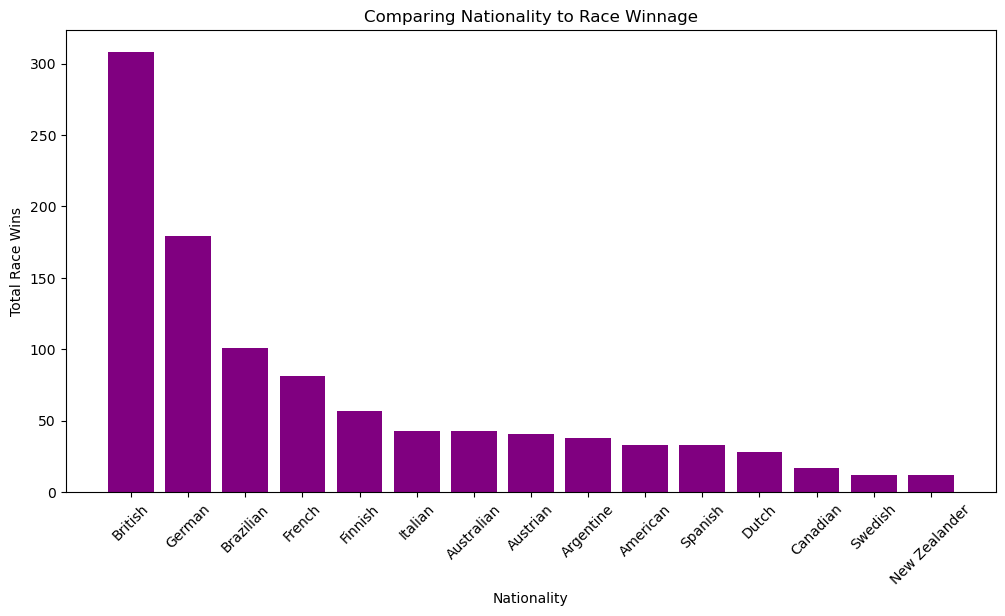

In [5]:
metrics_q1 = metrics_q1.sort_values('total_wins', ascending=False)
plt.figure(figsize=(12,6))
plt.bar('nationality', 'total_wins', data=metrics_q1.query('starts >= 100').head(15), color='purple')
plt.xticks(rotation=45)
plt.xlabel("Nationality")
plt.ylabel("Total Race Wins")
plt.title("Comparing Nationality to Race Winnage")
plt.show()

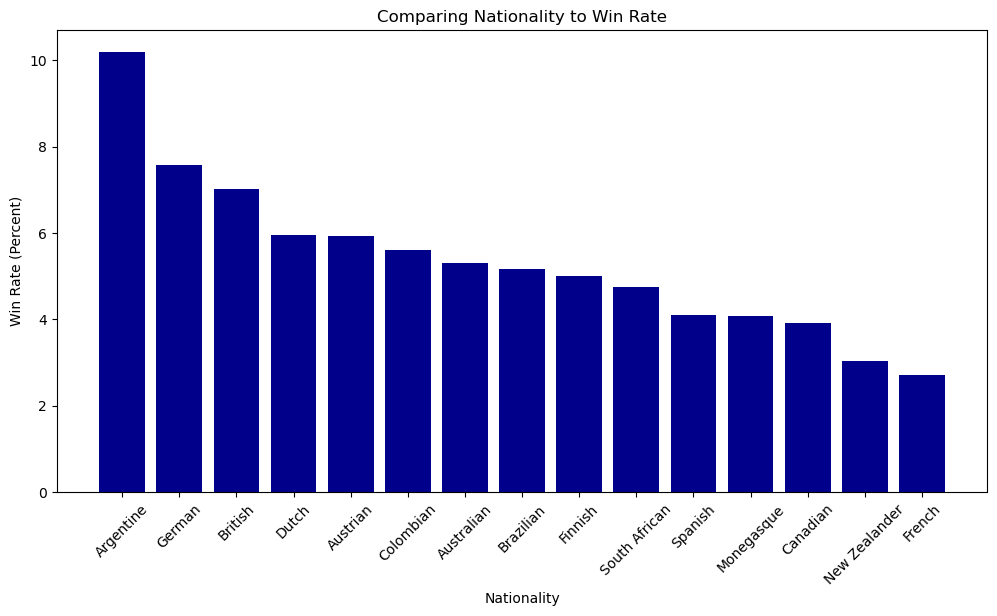

In [6]:
metrics_q1 = metrics_q1.sort_values('win_rate', ascending=False)
plt.figure(figsize=(12,6))
plt.bar('nationality', 'win_rate', data=metrics_q1.query('starts >= 100').head(15), color='darkblue')
plt.xticks(rotation=45)
plt.xlabel("Nationality")
plt.ylabel("Win Rate (Percent)")
plt.title("Comparing Nationality to Win Rate")
plt.show()

<font size = "10">

**QUESTION 2**

In [7]:
driver_results['age'] = driver_results['year'] - driver_results['dob_year']
yearly = driver_results.groupby('year').agg(
    avg_age = ('age', 'mean'),
    unique_nationalities = ('nationality', 'nunique'),
    unique_drivers = ('driverId', 'nunique')
).reset_index()
yearly['avg_age'] = round(yearly['avg_age']).astype(int)

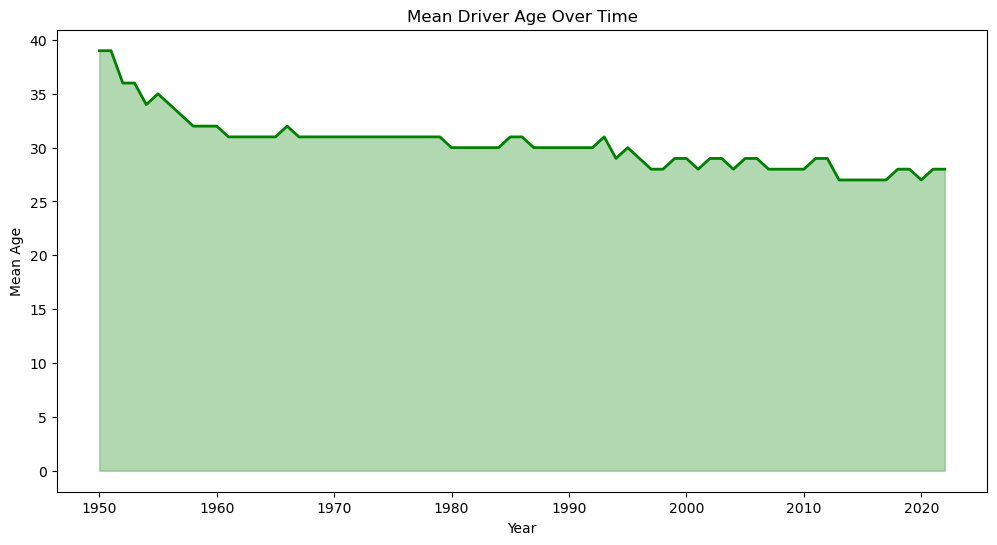

In [8]:
plt.figure(figsize=(12, 6))
plt.plot('year', 'avg_age', data=yearly, color='green', linewidth=2)
plt.fill_between(yearly['year'], yearly['avg_age'], alpha=0.3, color='green')
plt.xlabel("Year")
plt.ylabel("Mean Age")
plt.title("Mean Driver Age Over Time")
plt.show()

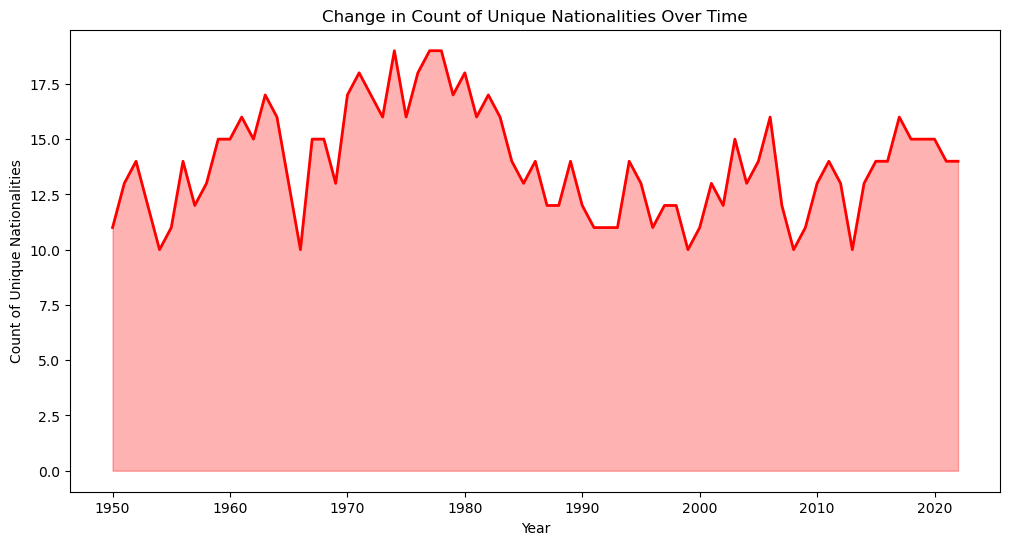

In [9]:
plt.figure(figsize=(12, 6))
plt.plot('year','unique_nationalities', data=yearly, color = 'red', linewidth=2)
plt.fill_between(yearly['year'], yearly['unique_nationalities'], alpha=0.3, color='red')
plt.xlabel("Year")
plt.ylabel("Count of Unique Nationalities")
plt.title("Change in Count of Unique Nationalities Over Time")
plt.show()

plt.show()

#### Discussion

Our findings show that success by nation in F1 follows two main patterns. Britain leads on every absolute measure (308 wins, 20 titles, 165 distinct drivers) through a strong supply of competitive drivers across decades. Germany and Argentina look very different. They have few distinct drivers but high win rates (7.57% and 10.19%), driven by generational talents like Schumacher and Fangio. France and Italy show the inverse, they have large driver pools that have low rates (2.71% and 1.26%). The leaderboard depends heavily on how "best" is defined, and restricting to nationalities with at least 100 starts was necessary to keep one time podiums from biasing the rankings.

We also found the typical F1 driver has also gotten younger and more "international" over time. Mean age fell from 39 in 1950 to 27 by 2013 and has held around 28 since then. This reflects the junior categories that now bring talent into F1 at the early 20s rather than admitting part time entrants in their 30s and 40s. National diversity peaked at 19 nationalities in 1974 and now sits at 14–15. This is more diverse than the 1950s but below the 1970s high. Part of the gap is likely just that modern grids only have around 20 drivers per season, compared to 60+ in the early years, so there are fewer slots for different nationalities to fill.